# EDA of Dataset Catalog

This notebook analyzes the `dataset_catalog.csv` file created from `dataset_catalog.json`. The goal is to understand the distribution of files across assemblies, specifically focusing on GFF availability.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set plotting style
sns.set_theme(style="whitegrid")

# Load the data
csv_path = "../dataset_catalog.csv"
df = pd.read_csv(csv_path)

print(f"Total rows in catalog: {len(df):,}")
df.head()

Total rows in catalog: 906,281


,accession,file_path,file_type,size_bytes
0,NaN,assembly_data_report.jsonl,DATA_REPORT,461425946
1,GCA_000320725.1,GCA_000320725.1/cds_from_genomic.fna,CDS_NUCLEOTIDE_FASTA,1111489
2,GCA_000320725.1,GCA_000320725.1/GCA_000320725.1_APLentilleviru...,GENOMIC_NUCLEOTIDE_FASTA,1209437
3,GCA_000320725.1,GCA_000320725.1/genomic.gff,GFF3,299386
4,GCA_000320725.1,GCA_000320725.1/protein.faa,PROTEIN_FASTA,389070


## Summary Statistics

Let's look at the basic statistics and handle any missing values.

In [2]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nUnique values:")
print(f"Accessions: {df['accession'].nunique():,}")
print(f"File types: {df['file_type'].nunique()}")

Missing values per column:
accession     1
file_path     0
file_type     0
size_bytes    0
dtype: int64

Unique values:
Accessions: 272,515
File types: 5


## Distribution of File Types

Which file types are most common in the dataset?

/var/folders/vc/z6j_dxbj4wl_jhtyr4jzsbw40000gn/T/ipykernel_36148/3679632191.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=file_type_counts.values, y=file_type_counts.index, palette='viridis')


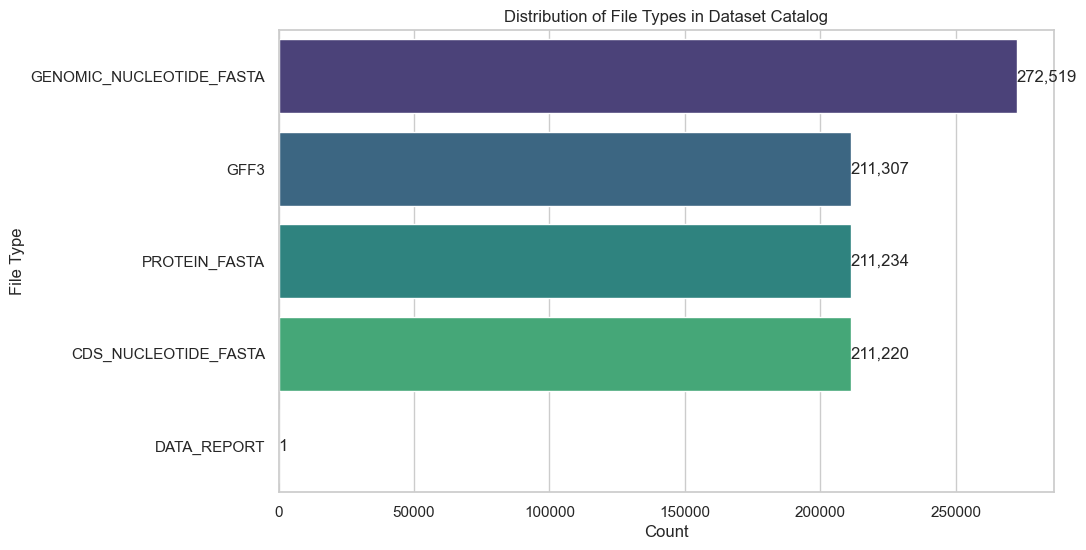

In [3]:
file_type_counts = df['file_type'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=file_type_counts.values, y=file_type_counts.index, palette='viridis')
plt.title('Distribution of File Types in Dataset Catalog')
plt.xlabel('Count')
plt.ylabel('File Type')
for i, v in enumerate(file_type_counts.values):
    plt.text(v + 3, i, f"{v:,}", va='center')
plt.show()

## GFF Availability

How many accessions have at least one GFF file? (File type 'GFF3')

In [2]:
# Filter for GFF3 files
gff_df = df[df['file_type'] == 'GFF3']
accessions_with_gff = gff_df['accession'].nunique()
total_accessions = df['accession'].nunique()

print(f"Accessions with GFF files: {accessions_with_gff:,}")
print(f"Total accessions in catalog: {total_accessions:,}")
print(f"Percentage: {accessions_with_gff / total_accessions * 100:.2f}%")

Accessions with GFF files: 211,307
Total accessions in catalog: 272,515
Percentage: 77.54%


In [3]:
df_subset = df[df['file_type'] == 'GFF3']

In [4]:
df_subset['accession']

3         GCA_000320725.1
8         GCA_000848265.1
15        GCA_000869685.1
21        GCA_000873825.1
26        GCA_000887755.1
               ...       
906263    GCF_000854525.1
906267    GCF_000861645.1
906271    GCF_004787635.1
906275    GCF_023124225.1
906279    GCF_029888005.1
Name: accession, Length: 211307, dtype: str

In [5]:
import os
import shutil

data_dir = '../viral_data_all/ncbi_dataset/data'
output_dir = '../viral_data_all/ncbi_dataset/data_subset'
os.makedirs(output_dir, exist_ok=True)

accessions = set(df_subset['accession'])

for accession in accessions:
    src_path = os.path.join(data_dir, accession)
    dst_path = os.path.join(output_dir, accession)
    if os.path.exists(src_path):
        shutil.move(src_path, dst_path)


## Average Files Per Accession

Mean files per accession: 3.33
Median files per accession: 4.0


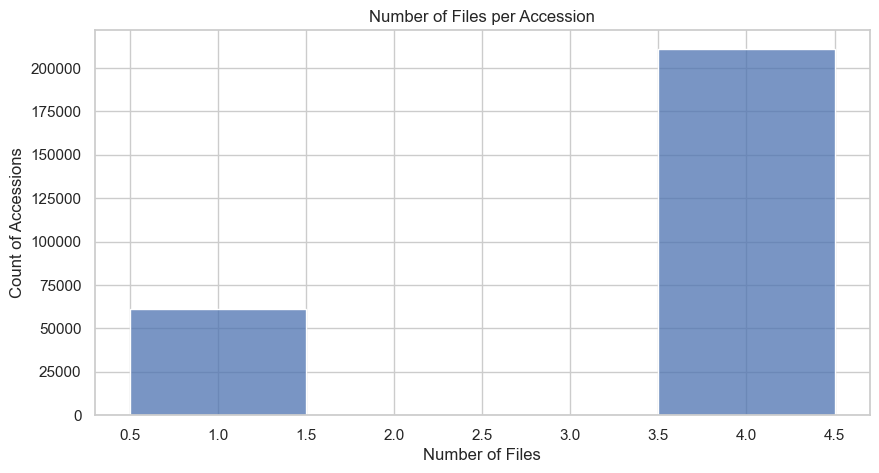

In [5]:
files_per_acc = df.groupby('accession').size()
print(f"Mean files per accession: {files_per_acc.mean():.2f}")
print(f"Median files per accession: {files_per_acc.median()}")

plt.figure(figsize=(10, 5))
sns.histplot(files_per_acc, bins=range(1, int(files_per_acc.max()) + 2), discrete=True)
plt.title('Number of Files per Accession')
plt.xlabel('Number of Files')
plt.ylabel('Count of Accessions')
plt.show()